## Full Data Science Notebook — Descriptive Stats + Hypothesis Testing + A/B Testing

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm

In [2]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
print("Mean age:", titanic['age'].mean())
print("Median age:", titanic['age'].median())
print("Std age:", titanic['age'].std())
print("Skewness:", titanic['age'].skew())

Mean age: 29.69911764705882
Median age: 28.0
Std age: 14.526497332334042
Skewness: 0.38910778230082704


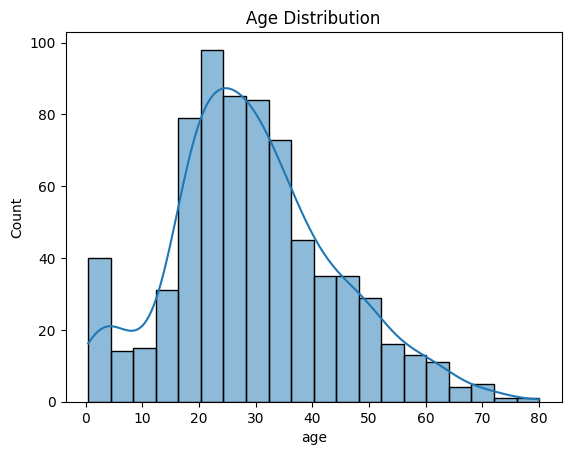

In [5]:
sns.histplot(titanic['age'].dropna(), kde=True)
plt.title("Age Distribution")
plt.show()

#### Insight
- Age is slightly right-skewed → more younger passengers
- Presence of missing values → needs preprocessing

### Hypothesis Testing (t-test)

In [6]:
survived = titanic[titanic['survived'] == 1]['age'].dropna()
not_survived = titanic[titanic['survived'] == 0]['age'].dropna()

stat, p = ttest_ind(survived, not_survived)
print(stat, p)

-2.06668694625381 0.039124654013482474


/var/folders/qb/x423dkzx7y352vrdk51r8_wm0000gn/T/ipykernel_29976/2119350833.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


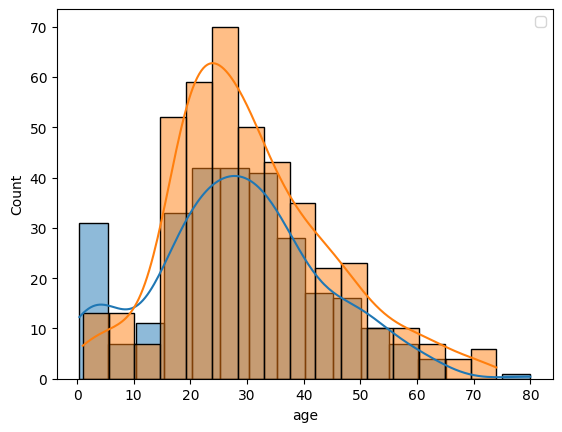

In [12]:
sns.histplot(survived, kde=True)
sns.histplot(not_survived, kde=True)
plt.legend()


### As p<0.5 which is 0.039124654013482474 , thats why age significanly affects survival

In [7]:
cont_table = pd.crosstab(titanic['sex'], titanic['survived'])
cont_table

survived,0,1
sex,,
female,81,233
male,468,109


In [8]:
chi2, p, _, _ = chi2_contingency(cont_table)
print(p)

1.1973570627755645e-58


#### Very low p-value(1.1973570627755645e-58) → Gender strongly impacts survival

In [9]:
cm = sm.stats.CompareMeans(
    sm.stats.DescrStatsW(survived),
    sm.stats.DescrStatsW(not_survived)
)

print(cm.tconfint_diff())

(np.float64(-4.450798156613018), np.float64(-0.11418102360818994))


✔ Titanic
Women had significantly higher survival rate
Age plays moderate role